# Lecture 21 · DDPM forward noising & $\varepsilon$-prediction reverse

**Goal** · build the diffusion forward process from scratch and verify three facts
numerically: (1) the closed form $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$
reproduces the lecture's worked number, (2) $\operatorname{Var}[x_t\mid x_0]=1-\bar\alpha_t$
grows to $\approx 1$ so $x_t\to\mathcal N(0,1)$, and (3) predicting the **noise** $\varepsilon$
is *equivalent* to predicting the true reverse **posterior mean**.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ---- Standard DDPM linear beta schedule --------------------------------------
T = 1000
beta = torch.linspace(1e-4, 0.02, T)      # beta_1 ... beta_T
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)   # cumulative product = alpha-bar_t

for t in [0, 250, 500, 750, 999]:
    print(f"t={t:4d}   beta_t={beta[t]:.5f}   alpha_bar_t={alpha_bar[t]:.4f}")

t=   0   beta_t=0.00010   alpha_bar_t=0.9999
t= 250   beta_t=0.00508   alpha_bar_t=0.5214
t= 500   beta_t=0.01006   alpha_bar_t=0.0778
t= 750   beta_t=0.01504   alpha_bar_t=0.0033
t= 999   beta_t=0.02000   alpha_bar_t=0.0000


## 1 · Closed-form forward — reproduce the lecture number

Lecture worked example: $x_0=[3.0,-1.0]$, a timestep with $\bar\alpha_t=0.36$
(so $\sqrt{\bar\alpha_t}=0.6$, $\sqrt{1-\bar\alpha_t}=0.8$), and noise
$\varepsilon=[0.5,1.0]$. The closed form should give $x_t=[2.2,\,0.2]$.

In [2]:
def forward_x_t(x0, ab, eps):
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * eps

x0  = torch.tensor([3.0, -1.0])
ab  = torch.tensor(0.36)
eps = torch.tensor([0.5, 1.0])

x_t = forward_x_t(x0, ab, eps)
print(f"sqrt(alpha_bar)   = {torch.sqrt(ab).item():.1f}")
print(f"sqrt(1-alpha_bar) = {torch.sqrt(1 - ab).item():.1f}")
print(f"x_t = {x_t.tolist()}   (lecture: [2.2, 0.2])")
assert torch.allclose(x_t, torch.tensor([2.2, 0.2]), atol=1e-6)

# alpha_bar = 0.5 is the 'halfway corruption' point where SNR = ab/(1-ab) = 1
print(f"\nSNR at alpha_bar=0.5: {0.5 / (1 - 0.5):.1f}  (signal power = noise power)")

sqrt(alpha_bar)   = 0.6
sqrt(1-alpha_bar) = 0.8
x_t = [2.200000047683716, 0.19999998807907104]   (lecture: [2.2, 0.2])

SNR at alpha_bar=0.5: 1.0  (signal power = noise power)


## 2 · The forward variance grows to 1 → $x_t\to\mathcal N(0,1)$

For a fixed $x_0$, $x_t$ is Gaussian with mean $\sqrt{\bar\alpha_t}\,x_0$ and variance
$1-\bar\alpha_t$. As $t$ grows, $\bar\alpha_t\to 0$: the mean is pulled to $0$ and the
variance to $1$. We check the empirical variance against $1-\bar\alpha_t$ and watch the
histogram of $x_t$ spread onto the standard normal.

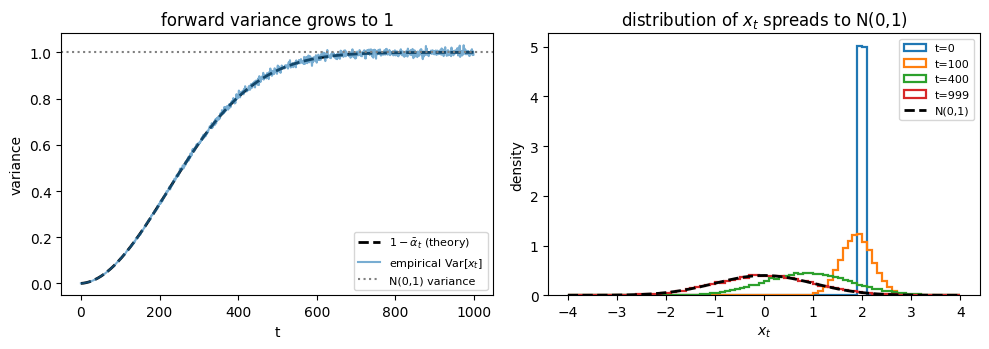

Var[x_t] at t=0:   0.0001   (~0, x_t == x_0)
Var[x_t] at t=999: 0.9905   (~1, pure noise)


In [3]:
x0_scalar = torch.tensor(2.0)          # a fixed 1-D data point
N = 20000
ts = torch.arange(0, T)
emp_var, theo_var = [], []
for t in ts:
    eps = torch.randn(N)
    xt = torch.sqrt(alpha_bar[t]) * x0_scalar + torch.sqrt(1 - alpha_bar[t]) * eps
    emp_var.append(xt.var().item())
    theo_var.append((1 - alpha_bar[t]).item())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(ts, theo_var, "k--", lw=2, label=r"$1-\bar\alpha_t$ (theory)")
ax[0].plot(ts, emp_var, alpha=0.6, label="empirical Var$[x_t]$")
ax[0].axhline(1.0, color="grey", ls=":", label="N(0,1) variance")
ax[0].set_xlabel("t"); ax[0].set_ylabel("variance"); ax[0].legend(fontsize=8)
ax[0].set_title("forward variance grows to 1")

grid = np.linspace(-4, 4, 300)
std_normal = np.exp(-0.5 * grid**2) / np.sqrt(2 * np.pi)
for t in [0, 100, 400, 999]:
    eps = torch.randn(N)
    xt = torch.sqrt(alpha_bar[t]) * x0_scalar + torch.sqrt(1 - alpha_bar[t]) * eps
    ax[1].hist(xt.numpy(), bins=80, range=(-4, 4), density=True,
               histtype="step", lw=1.6, label=f"t={t}")
ax[1].plot(grid, std_normal, "k--", lw=2, label="N(0,1)")
ax[1].set_xlabel(r"$x_t$"); ax[1].set_ylabel("density"); ax[1].legend(fontsize=8)
ax[1].set_title("distribution of $x_t$ spreads to N(0,1)")
plt.tight_layout(); plt.show()

print(f"Var[x_t] at t=0:   {emp_var[0]:.4f}   (~0, x_t == x_0)")
print(f"Var[x_t] at t=999: {emp_var[-1]:.4f}   (~1, pure noise)")

## 3 · Reverse: predicting $\varepsilon$ **is** predicting the posterior mean

The true reverse posterior $q(x_{t-1}\mid x_t,x_0)$ is Gaussian with mean

$$\tilde\mu_t(x_t,x_0)=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\,x_0
+\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,x_t .$$

Substituting $x_0=\dfrac{x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon}{\sqrt{\bar\alpha_t}}$
collapses this to the **$\varepsilon$-form** the network actually learns:

$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\!\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon\right).$$

If $\varepsilon$ is the *same* noise that formed $x_t$, both formulas must give the **same
number**. We verify that numerically.

In [4]:
def posterior_mean_x0(x_t, x0, t):
    ab_t, ab_prev = alpha_bar[t], alpha_bar[t - 1]
    c0 = torch.sqrt(ab_prev) * beta[t] / (1 - ab_t)
    ct = torch.sqrt(alpha[t]) * (1 - ab_prev) / (1 - ab_t)
    return c0 * x0 + ct * x_t

def posterior_mean_eps(x_t, eps, t):
    return (x_t - beta[t] / torch.sqrt(1 - alpha_bar[t]) * eps) / torch.sqrt(alpha[t])

# build a consistent (x0, eps, x_t) triple at some interior timestep
t = 500
x0_v = torch.tensor([2.0, 1.0])
eps_v = torch.randn(2)
x_t_v = forward_x_t(x0_v, alpha_bar[t], eps_v)

mu_from_x0  = posterior_mean_x0(x_t_v, x0_v, t)
mu_from_eps = posterior_mean_eps(x_t_v, eps_v, t)
print(f"alpha_bar[{t}] = {alpha_bar[t]:.4f}")
print(f"mu via x0-form  : {mu_from_x0.tolist()}")
print(f"mu via eps-form : {mu_from_eps.tolist()}")
print(f"max abs diff    : {(mu_from_x0 - mu_from_eps).abs().max().item():.2e}")
assert torch.allclose(mu_from_x0, mu_from_eps, atol=1e-5)

alpha_bar[500] = 0.0778
mu via x0-form  : [0.9036524891853333, -0.006231784820556641]
mu via eps-form : [0.9036524891853333, -0.006231783889234066]
max abs diff    : 9.31e-10


In [5]:
# Reproduce the lecture's 1-D reverse step (practice problem 5):
# x_t=2.0, alpha_t=0.8, alpha_bar_t=0.36, eps_theta=1.0 -> denoised mean.
xt_p, at_p, abt_p, eps_p = 2.0, 0.8, 0.36, 1.0
mu_p = (1 / np.sqrt(at_p)) * (xt_p - (1 - at_p) / np.sqrt(1 - abt_p) * eps_p)
print(f"denoised mean = {mu_p:.4f}   (moved from x_t=2.0 toward 0 -> denoising)")

denoised mean = 1.9566   (moved from x_t=2.0 toward 0 -> denoising)


## Takeaway
- **Forward** diffusion is a fixed, closed-form Gaussian noising:
  $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, whose variance
  climbs to $1$ so $x_T\approx\mathcal N(0,1)$ — no learning required.
- **Reverse** diffusion denoises. Predicting the noise $\varepsilon$ is algebraically the
  same as predicting the posterior mean $\tilde\mu_t$ (diff $\sim 10^{-6}$ above), which is
  why DDPMs train the network with a plain MSE-on-$\varepsilon$ objective.